<a href="https://www.kaggle.com/code/lalit7881/urban-air-pollution-analytics-eda?scriptVersionId=321492781" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/iconicwasil/global-urban-air-quality-and-pollution-time-series/global_urban_smog_pm25_hourly.csv


## LOADING DATASET

In [2]:
df = pd.read_csv("/kaggle/input/datasets/iconicwasil/global-urban-air-quality-and-pollution-time-series/global_urban_smog_pm25_hourly.csv")

In [3]:
df.head()

,Timestamp,City,Latitude,Longitude,PM10_ug_m3,PM2_5_ug_m3,Carbon_Monoxide_ug_m3,Nitrogen_Dioxide_ug_m3,Ozone_ug_m3,Dust_ug_m3,UV_Index,European_AQI,Hazardous_Event
0,2025-05-22T00:00,Lahore,31.5204,74.3587,186.7,74.3,926.0,22.9,94.0,197.0,0.0,76,0
1,2025-05-22T01:00,Lahore,31.5204,74.3587,286.8,96.4,736.0,18.1,103.0,356.0,0.0,77,0
2,2025-05-22T02:00,Lahore,31.5204,74.3587,380.0,122.0,599.0,14.1,110.0,506.0,0.0,78,0
3,2025-05-22T03:00,Lahore,31.5204,74.3587,486.2,149.9,548.0,11.7,114.0,640.0,0.0,80,0
4,2025-05-22T04:00,Lahore,31.5204,74.3587,581.1,172.8,550.0,10.1,118.0,765.0,0.0,85,0


In [4]:
df.tail()

,Timestamp,City,Latitude,Longitude,PM10_ug_m3,PM2_5_ug_m3,Carbon_Monoxide_ug_m3,Nitrogen_Dioxide_ug_m3,Ozone_ug_m3,Dust_ug_m3,UV_Index,European_AQI,Hazardous_Event
254731,2026-05-22T19:00,Buenos Aires,-34.6037,-58.3816,19.0,15.3,215.0,36.1,15.0,0.0,0.0,31,0
254732,2026-05-22T20:00,Buenos Aires,-34.6037,-58.3816,19.5,15.8,201.0,40.1,11.0,0.0,0.0,30,0
254733,2026-05-22T21:00,Buenos Aires,-34.6037,-58.3816,19.7,15.9,181.0,41.6,9.0,0.0,0.0,29,0
254734,2026-05-22T22:00,Buenos Aires,-34.6037,-58.3816,19.4,15.5,151.0,39.1,10.0,0.0,0.0,29,0
254735,2026-05-22T23:00,Buenos Aires,-34.6037,-58.3816,18.8,15.0,114.0,34.0,14.0,0.0,0.0,28,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254736 entries, 0 to 254735
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Timestamp               254736 non-null  object 
 1   City                    254736 non-null  object 
 2   Latitude                254736 non-null  float64
 3   Longitude               254736 non-null  float64
 4   PM10_ug_m3              254710 non-null  float64
 5   PM2_5_ug_m3             254736 non-null  float64
 6   Carbon_Monoxide_ug_m3   254736 non-null  float64
 7   Nitrogen_Dioxide_ug_m3  254736 non-null  float64
 8   Ozone_ug_m3             254736 non-null  float64
 9   Dust_ug_m3              254736 non-null  float64
 10  UV_Index                254736 non-null  float64
 11  European_AQI            254736 non-null  int64  
 12  Hazardous_Event         254736 non-null  int64  
dtypes: float64(9), int64(2), object(2)
memory usage: 25.3+ MB


In [6]:
df.describe()

,Latitude,Longitude,PM10_ug_m3,PM2_5_ug_m3,Carbon_Monoxide_ug_m3,Nitrogen_Dioxide_ug_m3,Ozone_ug_m3,Dust_ug_m3,UV_Index,European_AQI,Hazardous_Event
count,254736.000000,254736.000000,254710.000000,254736.000000,254736.000000,254736.000000,254736.000000,254736.000000,254736.000000,254736.000000,254736.000000
mean,22.189855,25.635590,87.306259,36.645918,697.997566,33.693697,60.943388,99.985825,1.388794,75.839449,0.132145
std,23.053334,74.682398,274.774559,40.993012,991.321463,27.581900,47.495866,525.500287,2.423290,101.027282,0.338649
min,-34.603700,-118.243700,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,0.000000
25%,13.756300,-46.633300,15.700000,12.900000,232.000000,12.800000,27.000000,0.000000,0.000000,34.000000,0.000000
50%,28.613900,37.617300,30.600000,22.900000,376.000000,25.100000,53.000000,1.000000,0.000000,61.000000,0.000000
75%,37.566500,77.209000,60.500000,44.500000,710.000000,47.700000,83.000000,13.000000,1.800000,78.000000,0.000000
max,55.755800,139.691700,3270.800000,624.000000,19081.000000,309.200000,523.000000,10166.000000,15.850000,1227.000000,1.000000


In [7]:
df.isnull()

,Timestamp,City,Latitude,Longitude,PM10_ug_m3,PM2_5_ug_m3,Carbon_Monoxide_ug_m3,Nitrogen_Dioxide_ug_m3,Ozone_ug_m3,Dust_ug_m3,UV_Index,European_AQI,Hazardous_Event
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
254731,False,False,False,False,False,False,False,False,False,False,False,False,False
254732,False,False,False,False,False,False,False,False,False,False,False,False,False
254733,False,False,False,False,False,False,False,False,False,False,False,False,False
254734,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

Timestamp                  0
City                       0
Latitude                   0
Longitude                  0
PM10_ug_m3                26
PM2_5_ug_m3                0
Carbon_Monoxide_ug_m3      0
Nitrogen_Dioxide_ug_m3     0
Ozone_ug_m3                0
Dust_ug_m3                 0
UV_Index                   0
European_AQI               0
Hazardous_Event            0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

Timestamp                  object
City                       object
Latitude                  float64
Longitude                 float64
PM10_ug_m3                float64
PM2_5_ug_m3               float64
Carbon_Monoxide_ug_m3     float64
Nitrogen_Dioxide_ug_m3    float64
Ozone_ug_m3               float64
Dust_ug_m3                float64
UV_Index                  float64
European_AQI                int64
Hazardous_Event             int64
dtype: object

In [11]:
df.shape

(254736, 13)

In [12]:
df.columns

Index(['Timestamp', 'City', 'Latitude', 'Longitude', 'PM10_ug_m3',
       'PM2_5_ug_m3', 'Carbon_Monoxide_ug_m3', 'Nitrogen_Dioxide_ug_m3',
       'Ozone_ug_m3', 'Dust_ug_m3', 'UV_Index', 'European_AQI',
       'Hazardous_Event'],
      dtype='object')

In [13]:
df.nunique()

Timestamp                 8784
City                        29
Latitude                    29
Longitude                   29
PM10_ug_m3                3036
PM2_5_ug_m3               1872
Carbon_Monoxide_ug_m3     6898
Nitrogen_Dioxide_ug_m3    1799
Ozone_ug_m3                392
Dust_ug_m3                4511
UV_Index                   291
European_AQI              1143
Hazardous_Event              2
dtype: int64

## EDA

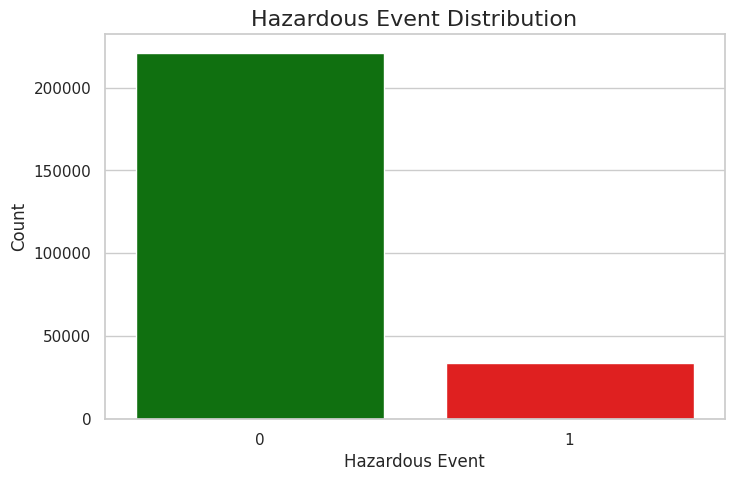

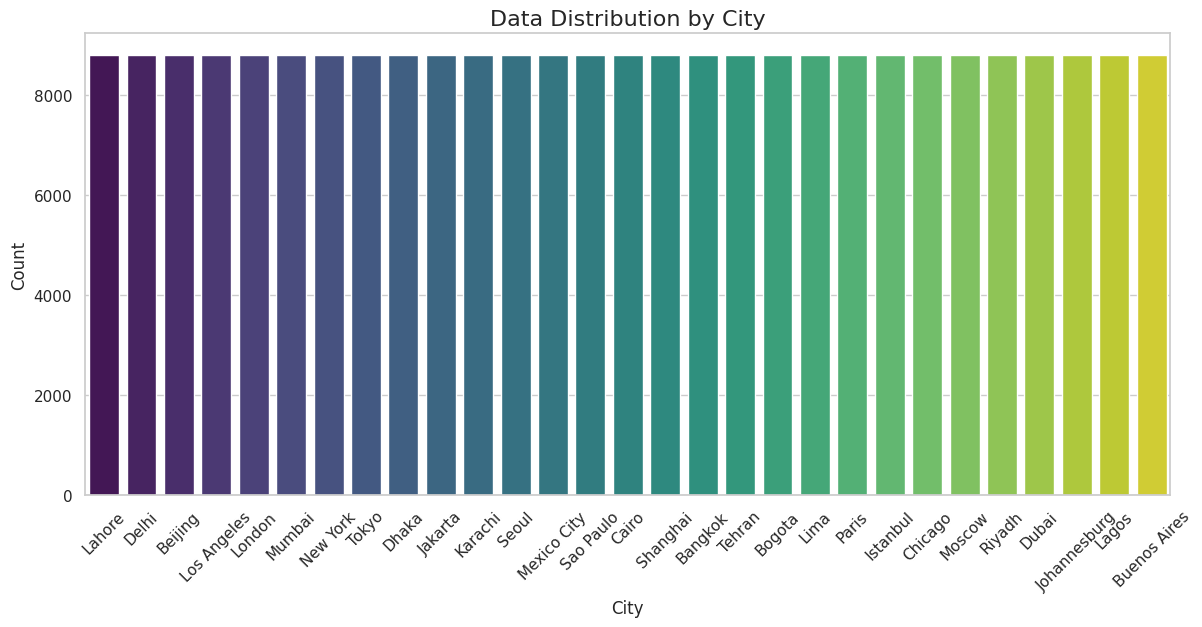

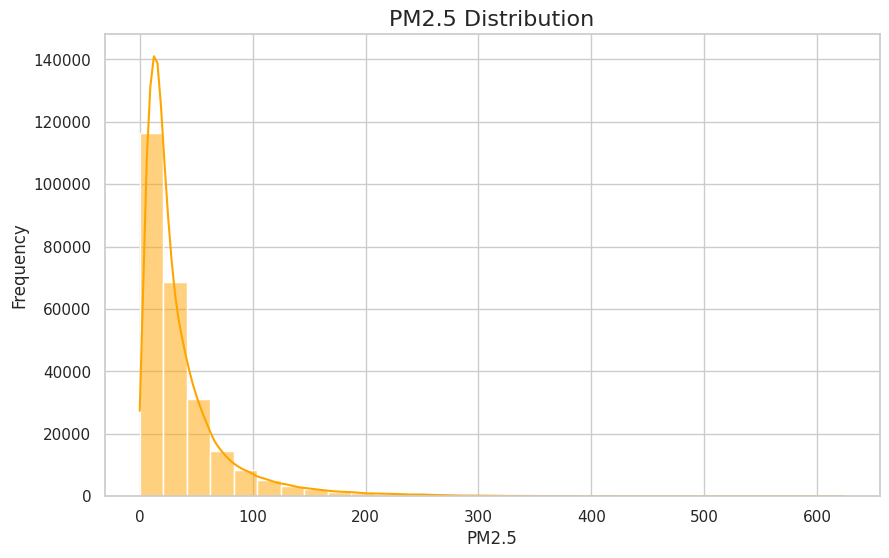

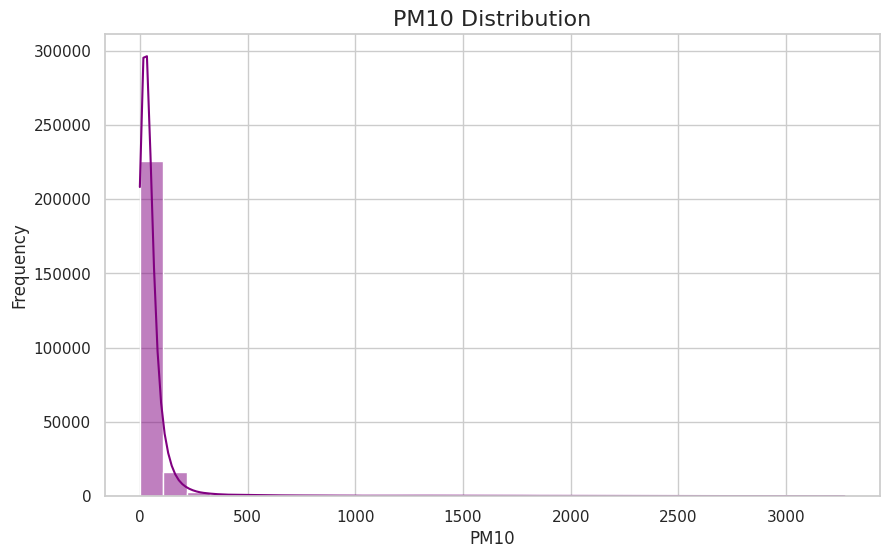

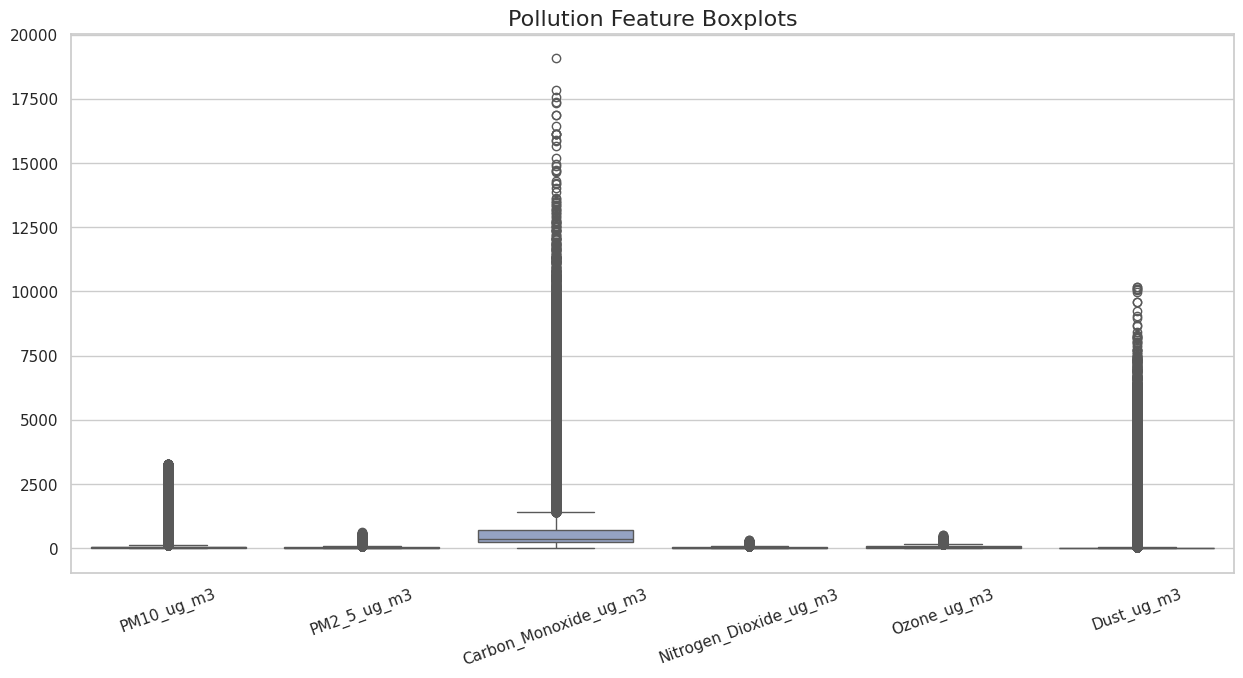

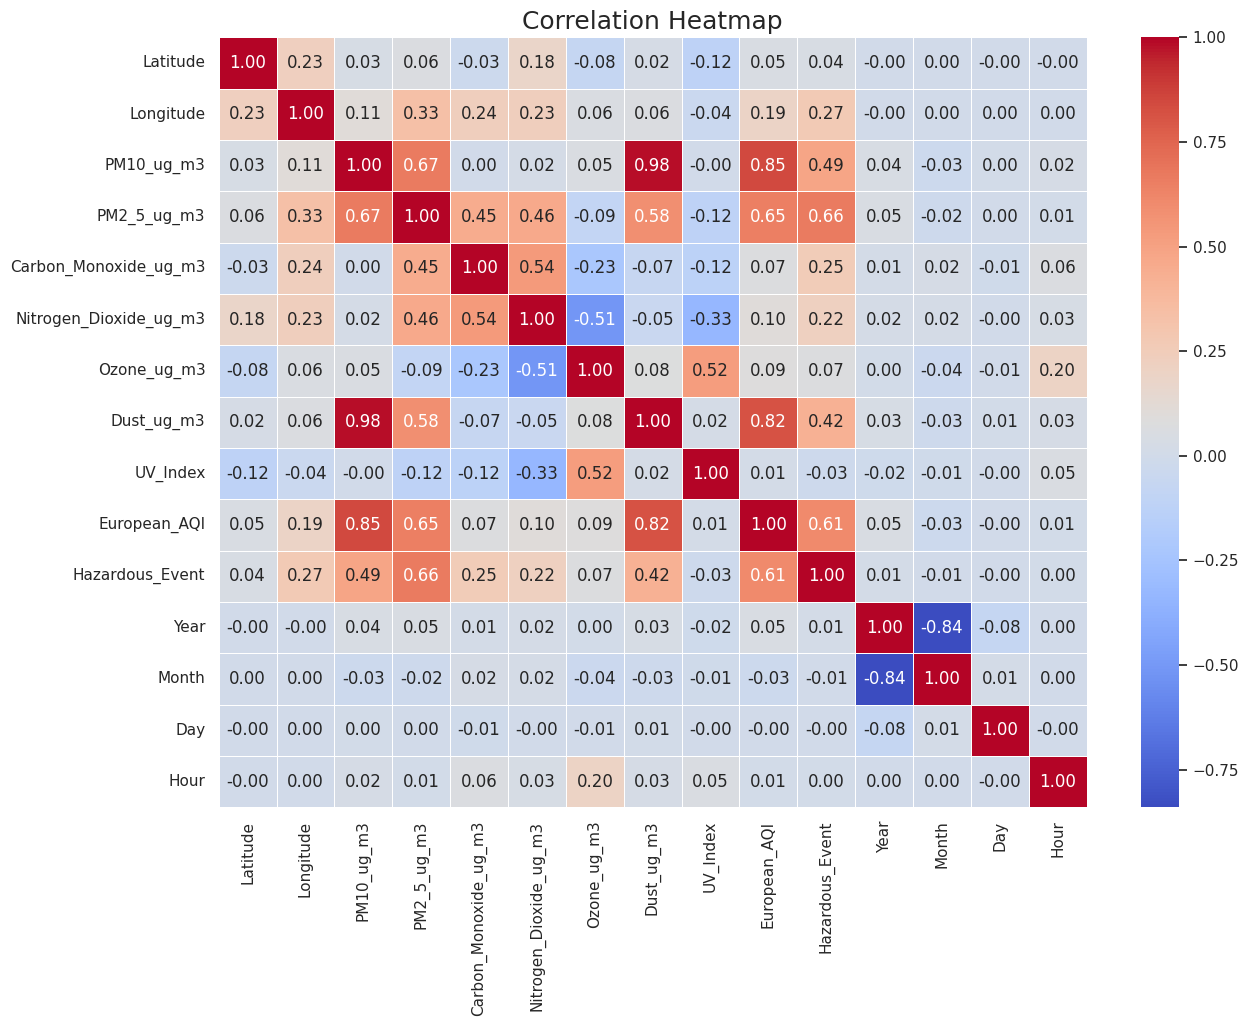

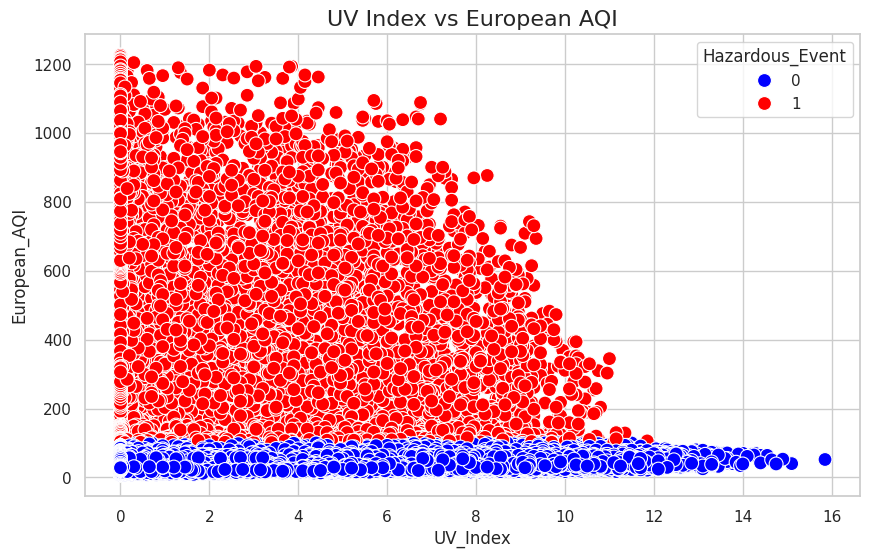

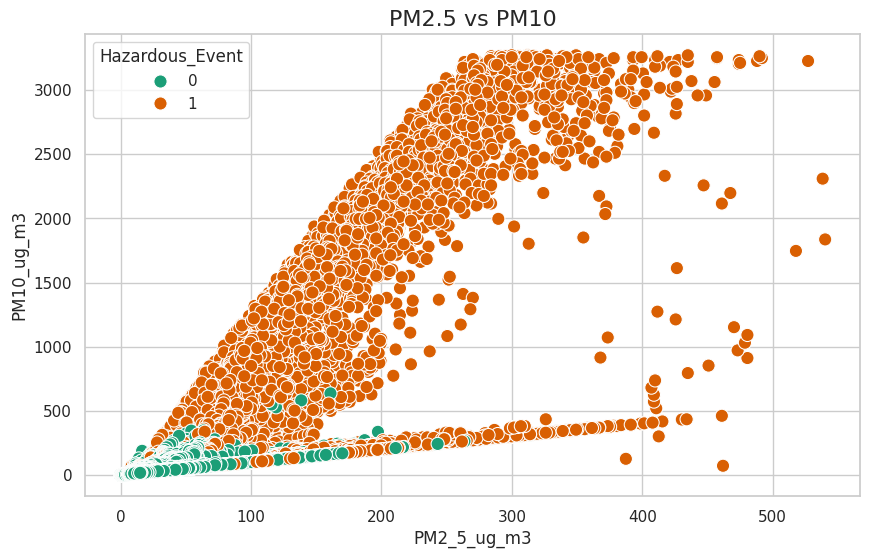

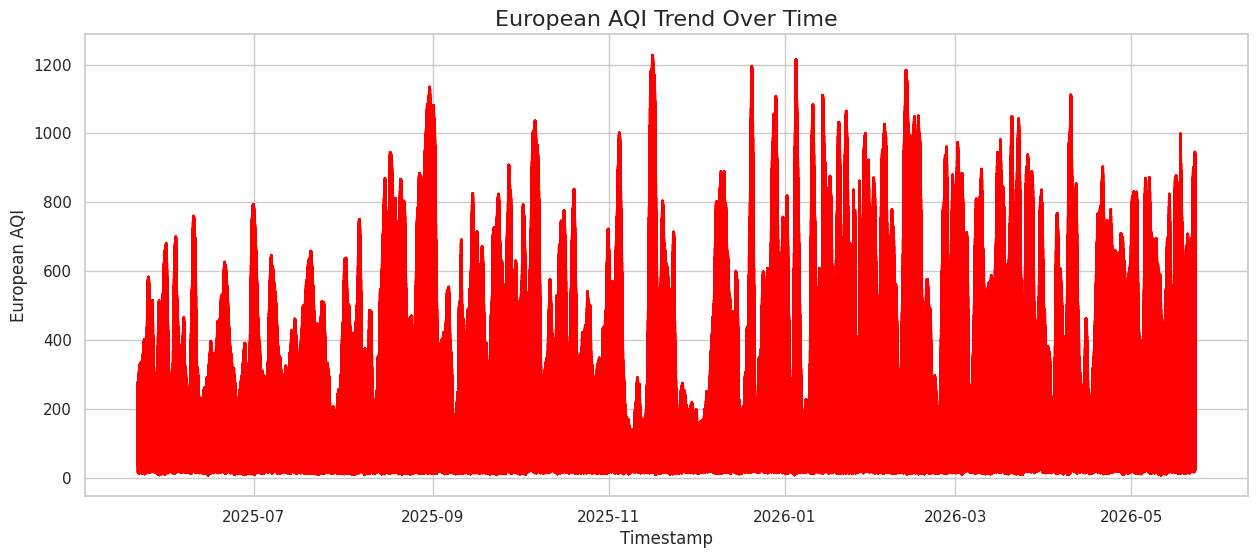

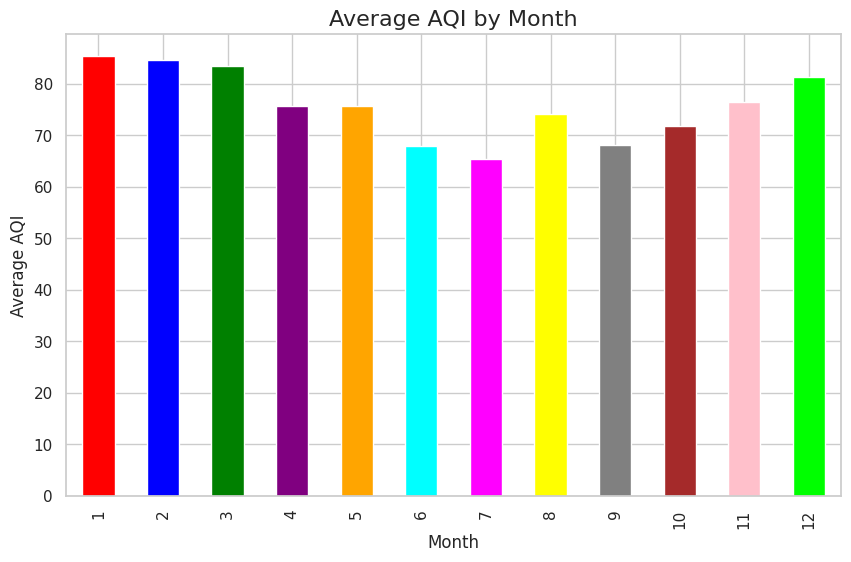

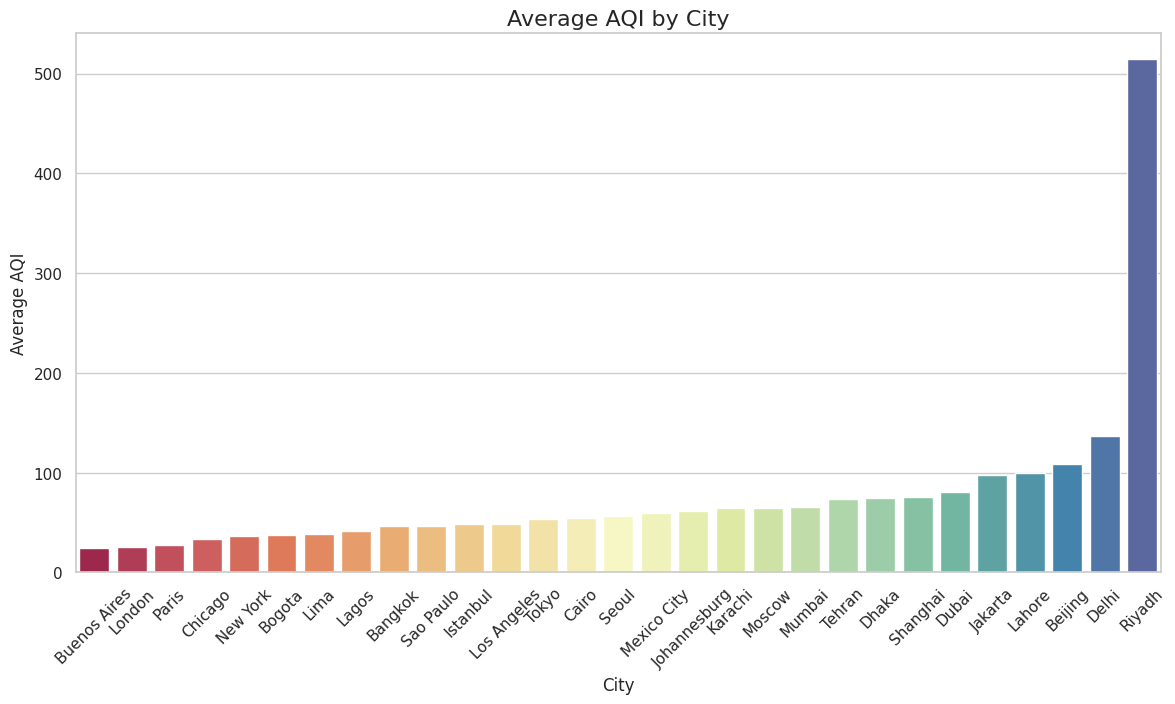

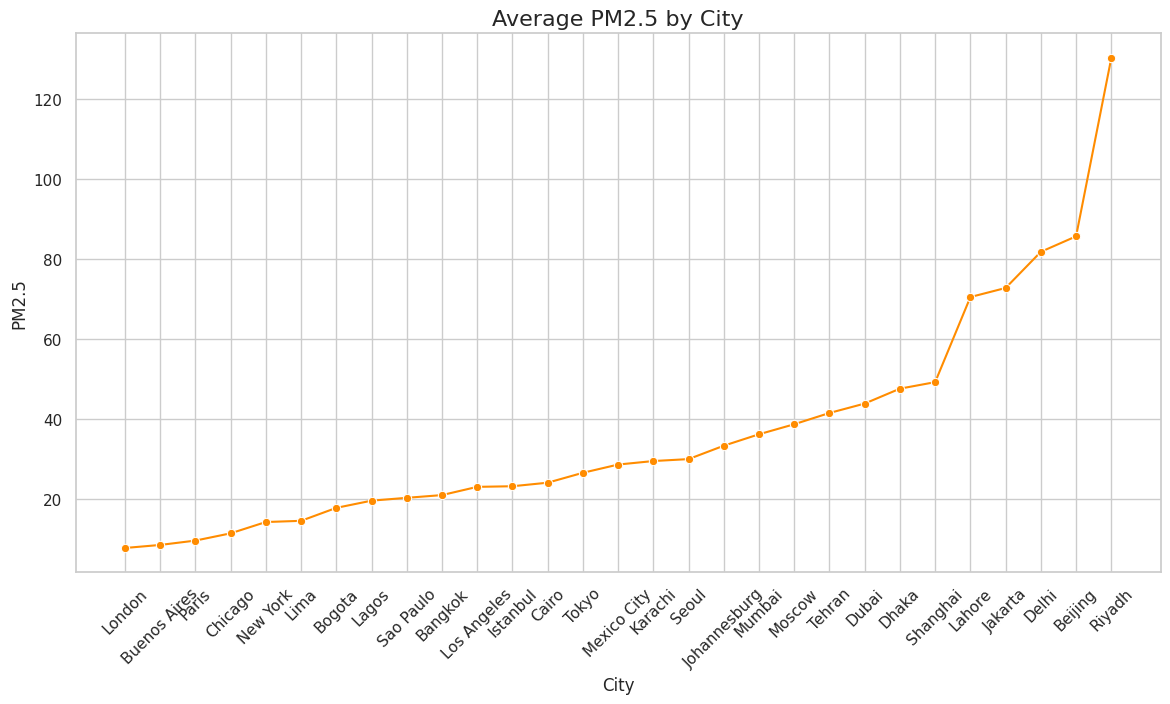

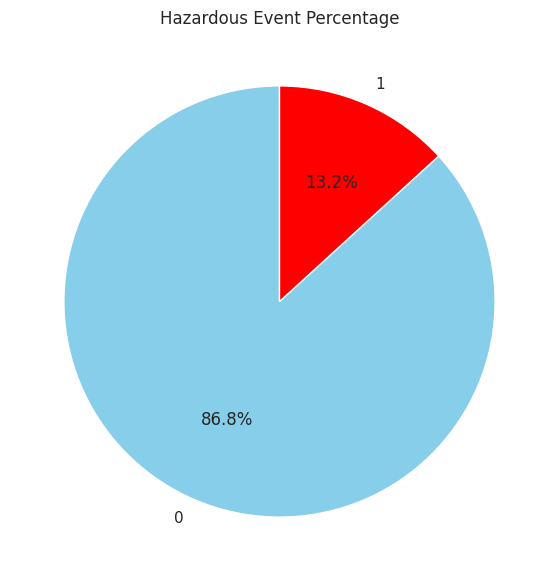

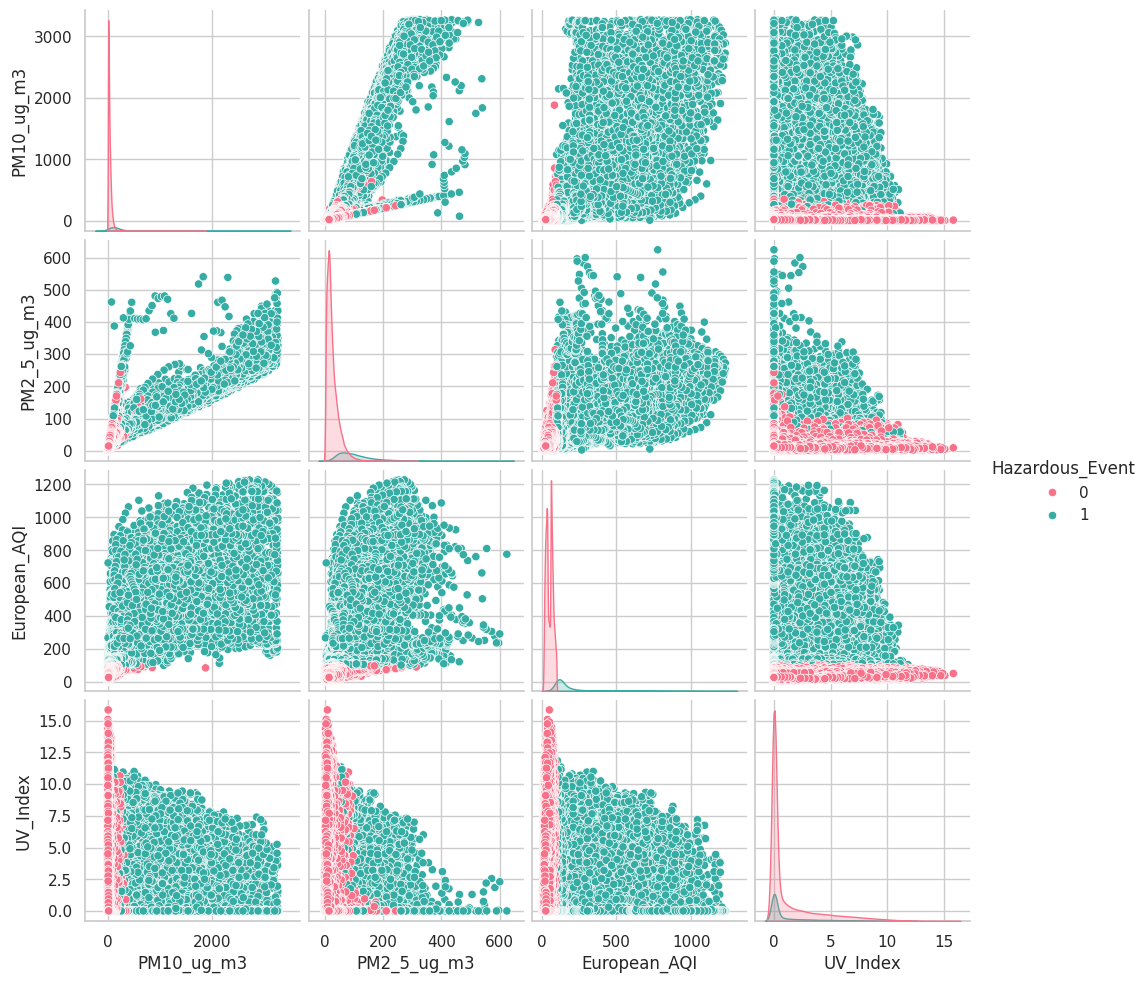

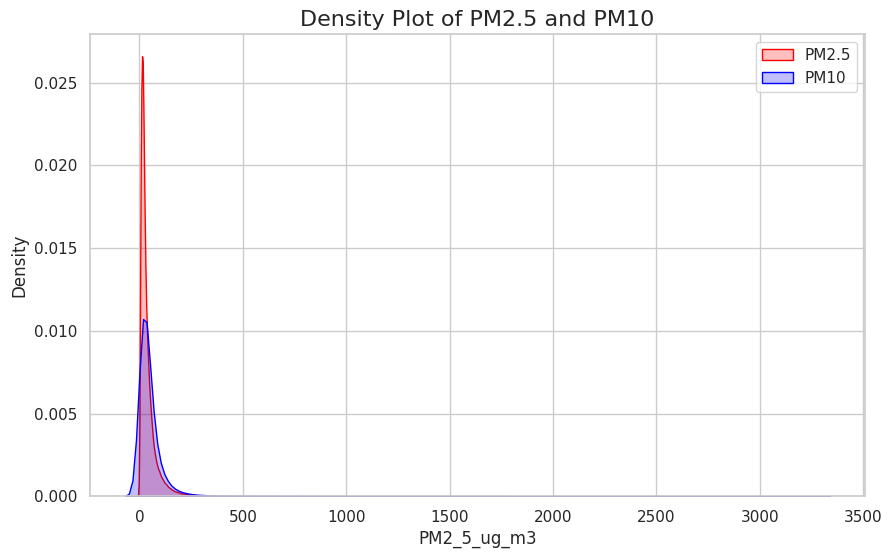

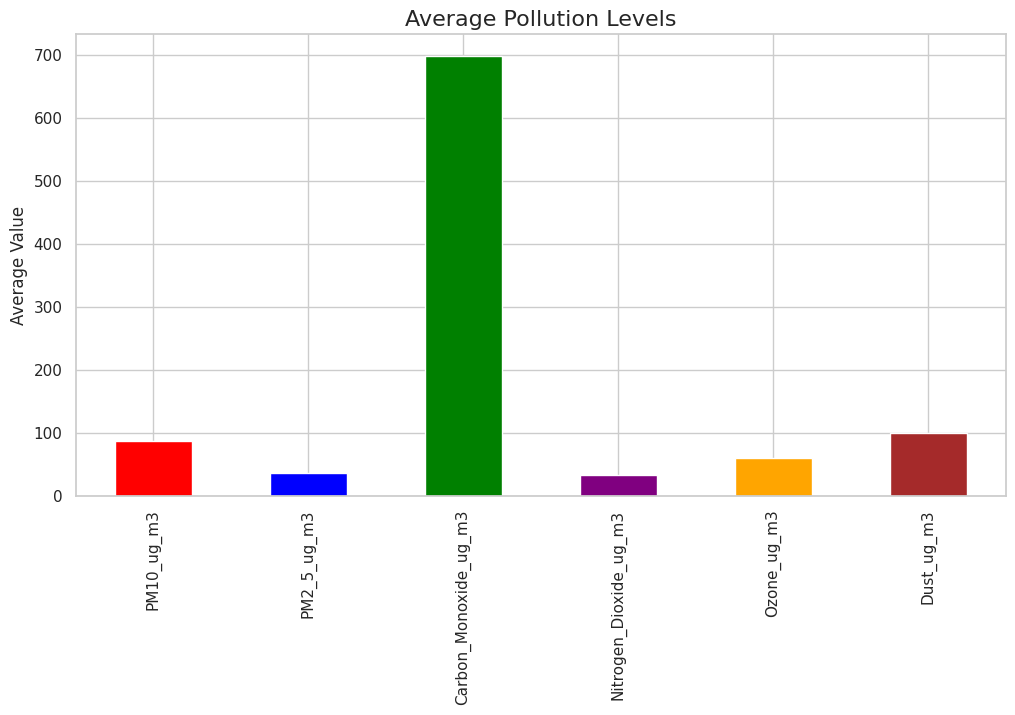

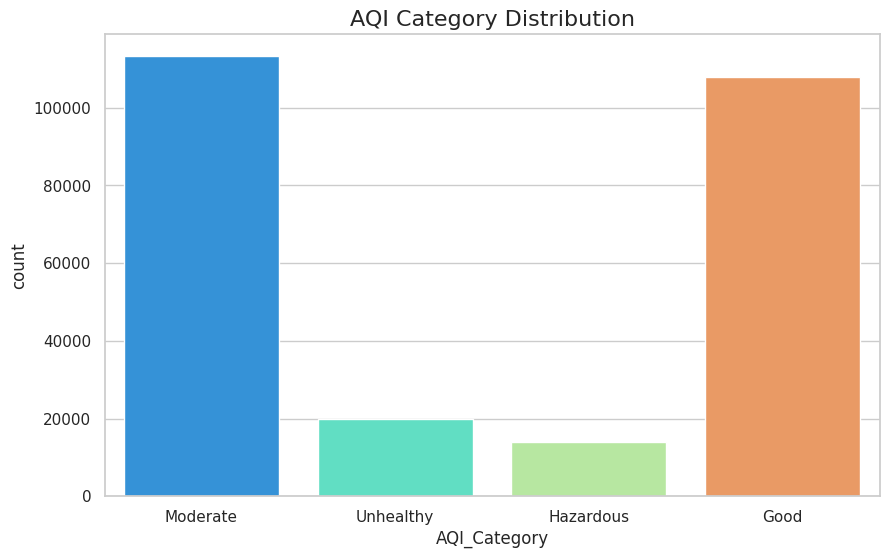

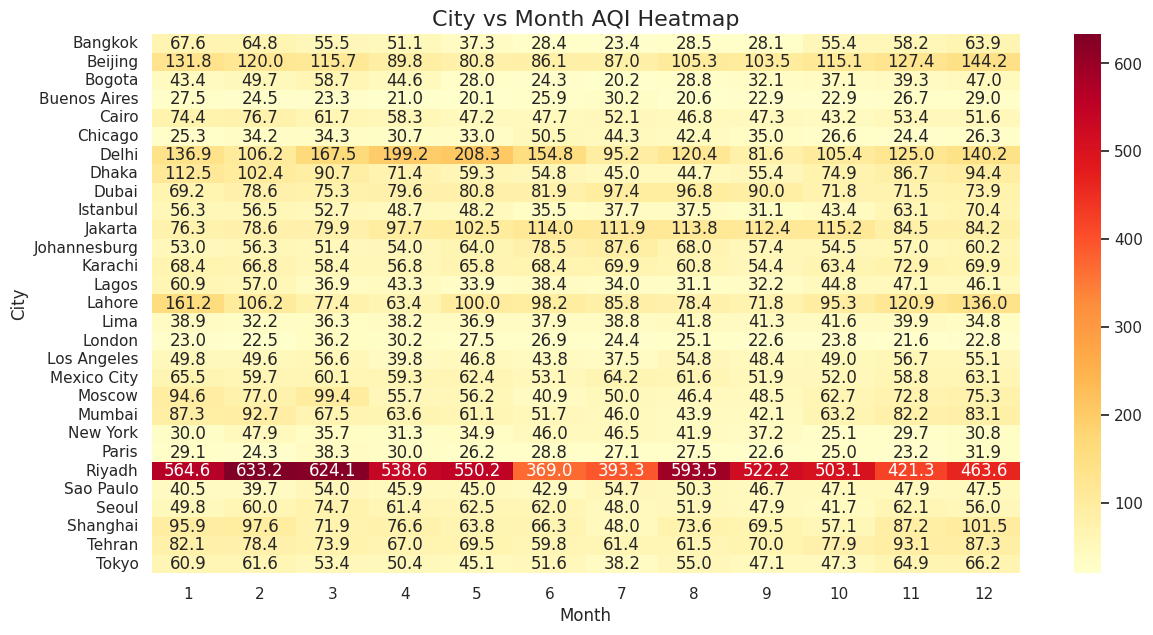

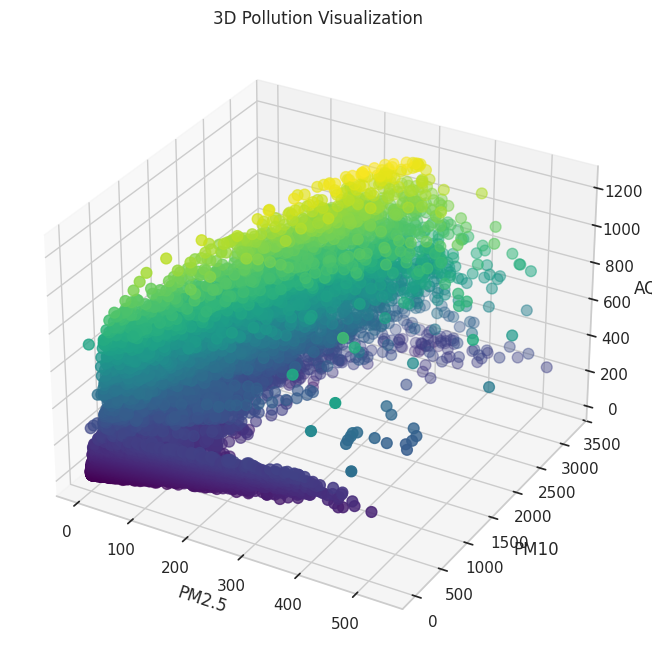

All visualizations generated successfully!


In [14]:
# =========================
# CONVERT TIMESTAMP
# =========================
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Extract time features
df['Year'] = df['Timestamp'].dt.year
df['Month'] = df['Timestamp'].dt.month
df['Day'] = df['Timestamp'].dt.day
df['Hour'] = df['Timestamp'].dt.hour

# =========================
# STYLE SETTINGS
# =========================
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

# ============================================
# 1. HAZARDOUS EVENT COUNT
# ============================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='Hazardous_Event',
    data=df,
    palette=['green', 'red']
)

plt.title("Hazardous Event Distribution", fontsize=16)
plt.xlabel("Hazardous Event")
plt.ylabel("Count")

plt.show()

# ============================================
# 2. CITY DISTRIBUTION
# ============================================

plt.figure(figsize=(14,6))

city_counts = df['City'].value_counts()

sns.barplot(
    x=city_counts.index,
    y=city_counts.values,
    palette='viridis'
)

plt.title("Data Distribution by City", fontsize=16)
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

# ============================================
# 3. PM2.5 DISTRIBUTION
# ============================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['PM2_5_ug_m3'],
    bins=30,
    kde=True,
    color='orange'
)

plt.title("PM2.5 Distribution", fontsize=16)
plt.xlabel("PM2.5")
plt.ylabel("Frequency")

plt.show()

# ============================================
# 4. PM10 DISTRIBUTION
# ============================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['PM10_ug_m3'],
    bins=30,
    kde=True,
    color='purple'
)

plt.title("PM10 Distribution", fontsize=16)
plt.xlabel("PM10")
plt.ylabel("Frequency")

plt.show()

# ============================================
# 5. AIR POLLUTION BOXPLOTS
# ============================================

pollution_cols = [
    'PM10_ug_m3',
    'PM2_5_ug_m3',
    'Carbon_Monoxide_ug_m3',
    'Nitrogen_Dioxide_ug_m3',
    'Ozone_ug_m3',
    'Dust_ug_m3'
]

plt.figure(figsize=(15,7))

sns.boxplot(
    data=df[pollution_cols],
    palette='Set2'
)

plt.title("Pollution Feature Boxplots", fontsize=16)
plt.xticks(rotation=20)

plt.show()

# ============================================
# 6. CORRELATION HEATMAP
# ============================================

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=18)

plt.show()

# ============================================
# 7. UV INDEX VS EUROPEAN AQI
# ============================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='UV_Index',
    y='European_AQI',
    hue='Hazardous_Event',
    palette=['blue', 'red'],
    data=df,
    s=100
)

plt.title("UV Index vs European AQI", fontsize=16)

plt.show()

# ============================================
# 8. PM2.5 VS PM10
# ============================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='PM2_5_ug_m3',
    y='PM10_ug_m3',
    hue='Hazardous_Event',
    palette='Dark2',
    data=df,
    s=90
)

plt.title("PM2.5 vs PM10", fontsize=16)

plt.show()

# ============================================
# 9. AQI TREND OVER TIME
# ============================================

df_sorted = df.sort_values('Timestamp')

plt.figure(figsize=(15,6))

plt.plot(
    df_sorted['Timestamp'],
    df_sorted['European_AQI'],
    color='red',
    linewidth=2
)

plt.title("European AQI Trend Over Time", fontsize=16)
plt.xlabel("Timestamp")
plt.ylabel("European AQI")

plt.show()

# ============================================
# 10. MONTHLY AQI AVERAGE
# ============================================

monthly_aqi = df.groupby('Month')['European_AQI'].mean()

plt.figure(figsize=(10,6))

monthly_aqi.plot(
    kind='bar',
    color=['red','blue','green','purple','orange',
           'cyan','magenta','yellow','gray','brown',
           'pink','lime']
)

plt.title("Average AQI by Month", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Average AQI")

plt.show()

# ============================================
# 11. CITY-WISE AQI
# ============================================

city_aqi = df.groupby('City')['European_AQI'].mean().sort_values()

plt.figure(figsize=(14,7))

sns.barplot(
    x=city_aqi.index,
    y=city_aqi.values,
    palette='Spectral'
)

plt.title("Average AQI by City", fontsize=16)
plt.xlabel("City")
plt.ylabel("Average AQI")
plt.xticks(rotation=45)

plt.show()

# ============================================
# 12. CITY-WISE PM2.5
# ============================================

city_pm25 = df.groupby('City')['PM2_5_ug_m3'].mean().sort_values()

plt.figure(figsize=(14,7))

sns.lineplot(
    x=city_pm25.index,
    y=city_pm25.values,
    marker='o',
    color='darkorange'
)

plt.title("Average PM2.5 by City", fontsize=16)
plt.xlabel("City")
plt.ylabel("PM2.5")
plt.xticks(rotation=45)

plt.show()

# ============================================
# 13. PIE CHART FOR HAZARDOUS EVENTS
# ============================================

hazard_counts = df['Hazardous_Event'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    hazard_counts,
    labels=hazard_counts.index,
    autopct='%1.1f%%',
    colors=['skyblue', 'red'],
    startangle=90
)

plt.title("Hazardous Event Percentage")

plt.show()

# ============================================
# 14. PAIRPLOT
# ============================================

pairplot_cols = [
    'PM10_ug_m3',
    'PM2_5_ug_m3',
    'European_AQI',
    'UV_Index',
    'Hazardous_Event'
]

sns.pairplot(
    df[pairplot_cols],
    hue='Hazardous_Event',
    palette='husl'
)

plt.show()

# ============================================
# 15. KDE PLOTS
# ============================================

plt.figure(figsize=(10,6))

sns.kdeplot(
    df['PM2_5_ug_m3'],
    shade=True,
    color='red',
    label='PM2.5'
)

sns.kdeplot(
    df['PM10_ug_m3'],
    shade=True,
    color='blue',
    label='PM10'
)

plt.title("Density Plot of PM2.5 and PM10", fontsize=16)

plt.legend()

plt.show()

# ============================================
# 16. POLLUTION COMPARISON
# ============================================

avg_pollution = df[pollution_cols].mean()

plt.figure(figsize=(12,6))

avg_pollution.plot(
    kind='bar',
    color=['red','blue','green','purple','orange','brown']
)

plt.title("Average Pollution Levels", fontsize=16)
plt.ylabel("Average Value")

plt.show()

# ============================================
# 17. AQI CATEGORY CREATION
# ============================================

def categorize_aqi(aqi):
    if aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Moderate'
    elif aqi <= 150:
        return 'Unhealthy'
    else:
        return 'Hazardous'

df['AQI_Category'] = df['European_AQI'].apply(categorize_aqi)

# ============================================
# 18. AQI CATEGORY VISUALIZATION
# ============================================

plt.figure(figsize=(10,6))

sns.countplot(
    x='AQI_Category',
    data=df,
    palette='rainbow'
)

plt.title("AQI Category Distribution", fontsize=16)

plt.show()

# ============================================
# 19. HEATMAP OF CITY VS AQI
# ============================================

pivot_table = df.pivot_table(
    values='European_AQI',
    index='City',
    columns='Month',
    aggfunc='mean'
)

plt.figure(figsize=(14,7))

sns.heatmap(
    pivot_table,
    cmap='YlOrRd',
    annot=True,
    fmt='.1f'
)

plt.title("City vs Month AQI Heatmap", fontsize=16)

plt.show()

# ============================================
# 20. 3D SCATTER PLOT
# ============================================

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12,8))

ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['PM2_5_ug_m3'],
    df['PM10_ug_m3'],
    df['European_AQI'],
    c=df['European_AQI'],
    cmap='viridis',
    s=60
)

ax.set_xlabel("PM2.5")
ax.set_ylabel("PM10")
ax.set_zlabel("AQI")

plt.title("3D Pollution Visualization")

plt.show()

# ============================================
# COMPLETED
# ============================================

print("All visualizations generated successfully!")

## Feature Engineering

In [15]:
# Train Test Split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    RocCurveDisplay
)




Target Classes:
[0 1]

Categorical Columns:
['City', 'AQI_Category']

Numerical Columns:
['Latitude', 'Longitude', 'PM10_ug_m3', 'PM2_5_ug_m3', 'Carbon_Monoxide_ug_m3', 'Nitrogen_Dioxide_ug_m3', 'Ozone_ug_m3', 'Dust_ug_m3', 'UV_Index', 'European_AQI', 'Year', 'Month', 'Day', 'Hour']

Training Shape : (203788, 16)
Testing Shape  : (50948, 16)


MODEL : Logistic Regression

Accuracy Score : 1.0000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     44215
           1       1.00      1.00      1.00      6733

    accuracy                           1.00     50948
   macro avg       1.00      1.00      1.00     50948
weighted avg       1.00      1.00      1.00     50948


Confusion Matrix:

[[44214     1]
 [    0  6733]]


<Figure size 1200x800 with 0 Axes>

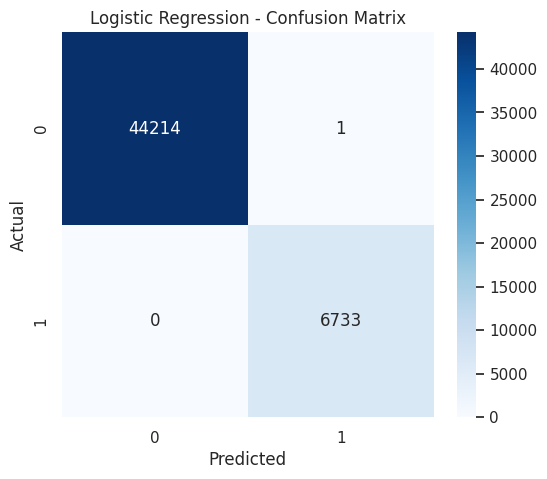



MODEL : Decision Tree

Accuracy Score : 1.0000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     44215
           1       1.00      1.00      1.00      6733

    accuracy                           1.00     50948
   macro avg       1.00      1.00      1.00     50948
weighted avg       1.00      1.00      1.00     50948


Confusion Matrix:

[[44215     0]
 [    0  6733]]


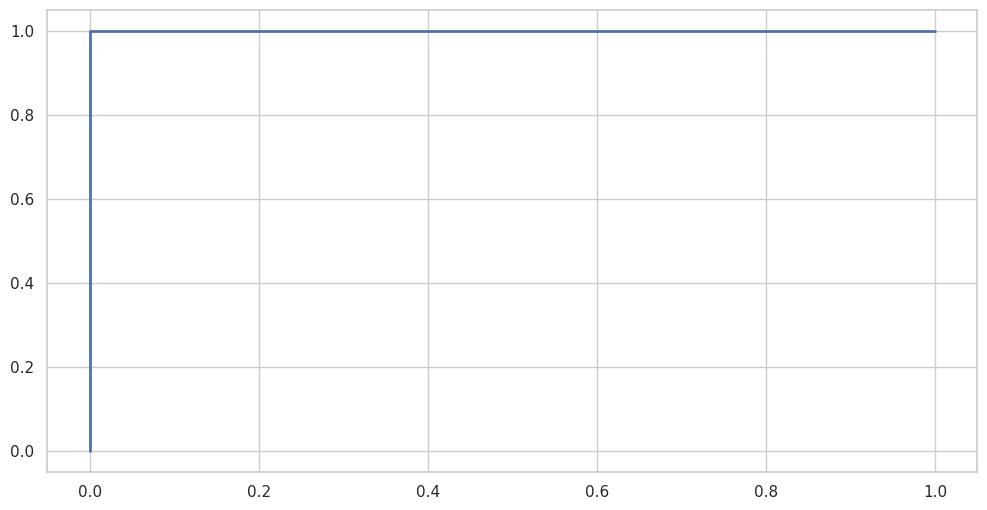

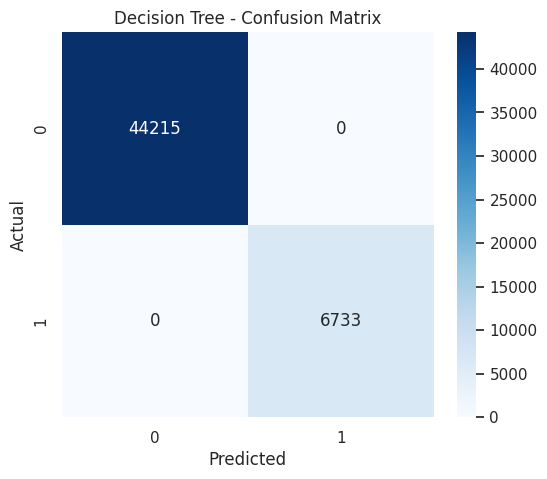



MODEL : Random Forest

Accuracy Score : 1.0000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     44215
           1       1.00      1.00      1.00      6733

    accuracy                           1.00     50948
   macro avg       1.00      1.00      1.00     50948
weighted avg       1.00      1.00      1.00     50948


Confusion Matrix:

[[44215     0]
 [    0  6733]]


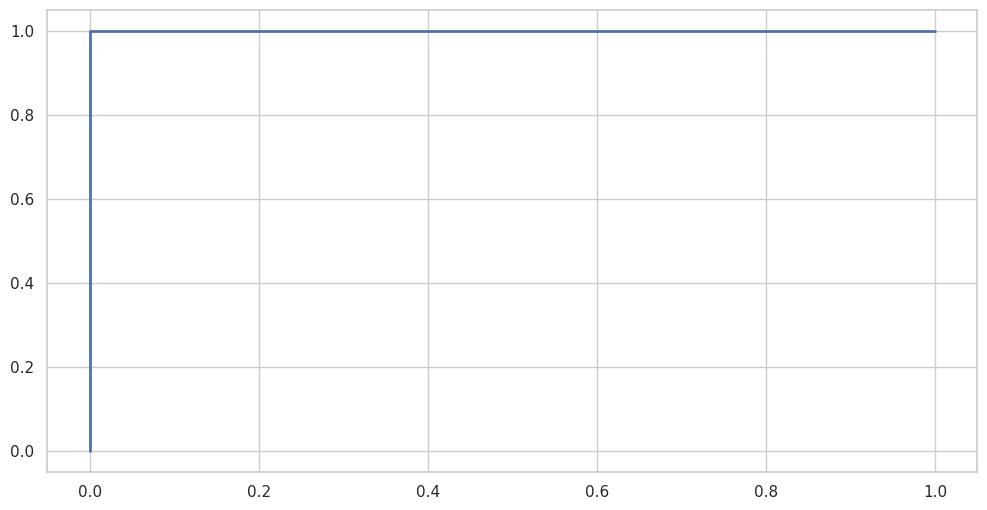

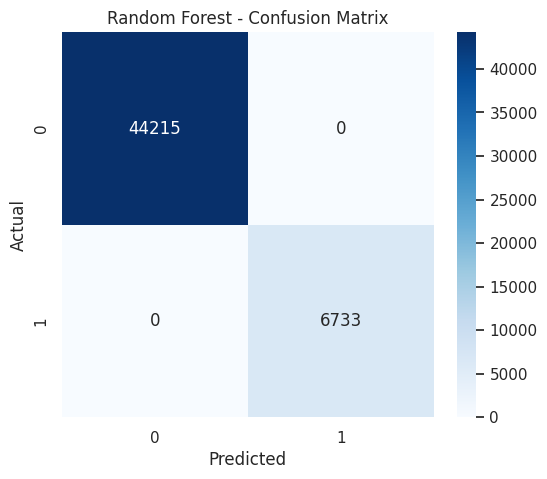



MODEL : Gradient Boosting

Accuracy Score : 1.0000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     44215
           1       1.00      1.00      1.00      6733

    accuracy                           1.00     50948
   macro avg       1.00      1.00      1.00     50948
weighted avg       1.00      1.00      1.00     50948


Confusion Matrix:

[[44215     0]
 [    0  6733]]


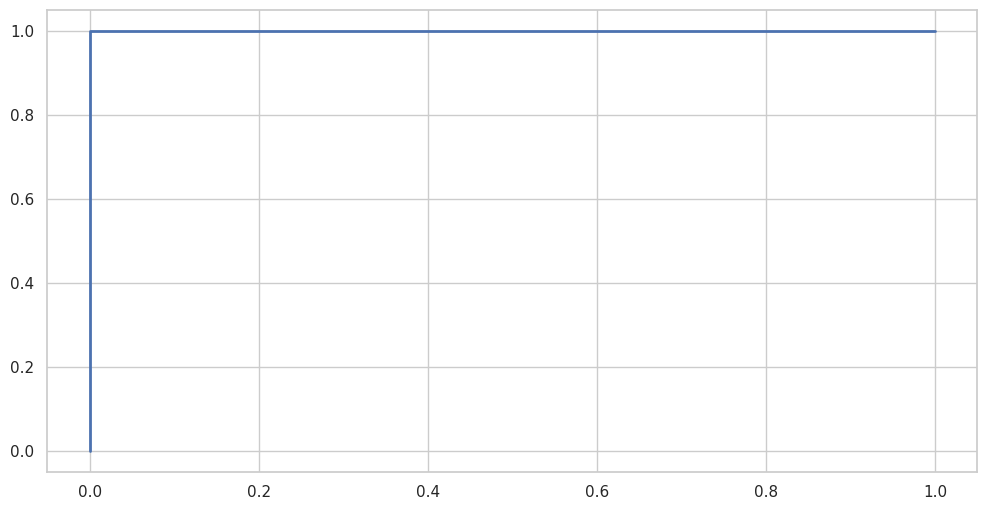

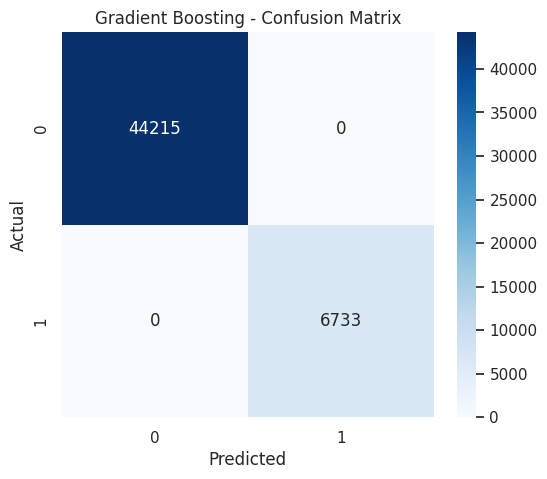



MODEL : Support Vector Machine

Accuracy Score : 1.0000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     44215
           1       1.00      1.00      1.00      6733

    accuracy                           1.00     50948
   macro avg       1.00      1.00      1.00     50948
weighted avg       1.00      1.00      1.00     50948


Confusion Matrix:

[[44214     1]
 [    0  6733]]


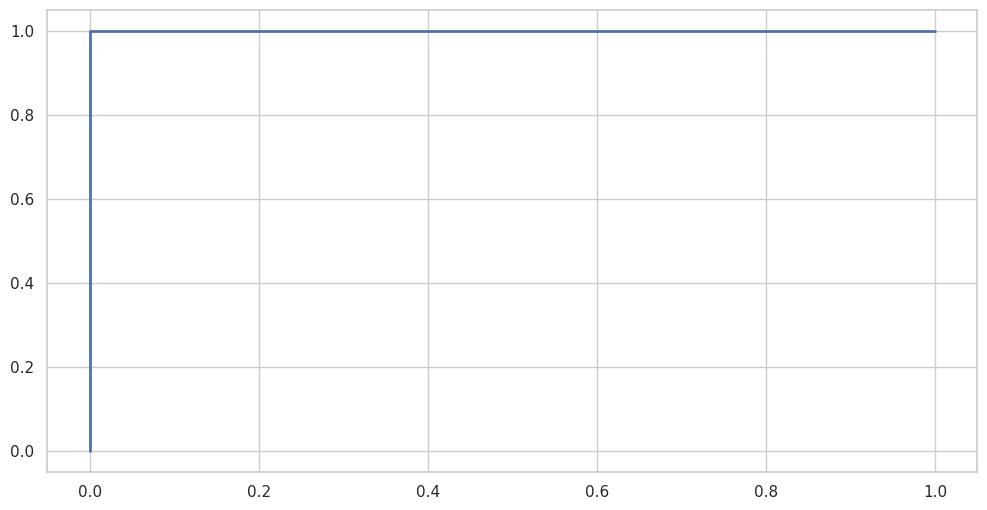

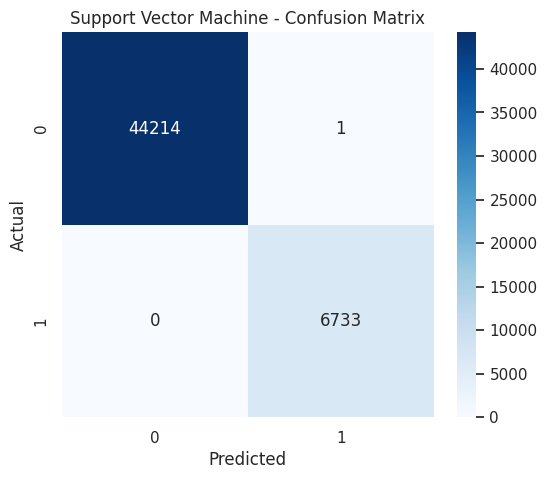



MODEL : K-Nearest Neighbors

Accuracy Score : 0.9996

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     44215
           1       1.00      1.00      1.00      6733

    accuracy                           1.00     50948
   macro avg       1.00      1.00      1.00     50948
weighted avg       1.00      1.00      1.00     50948


Confusion Matrix:

[[44204    11]
 [   10  6723]]


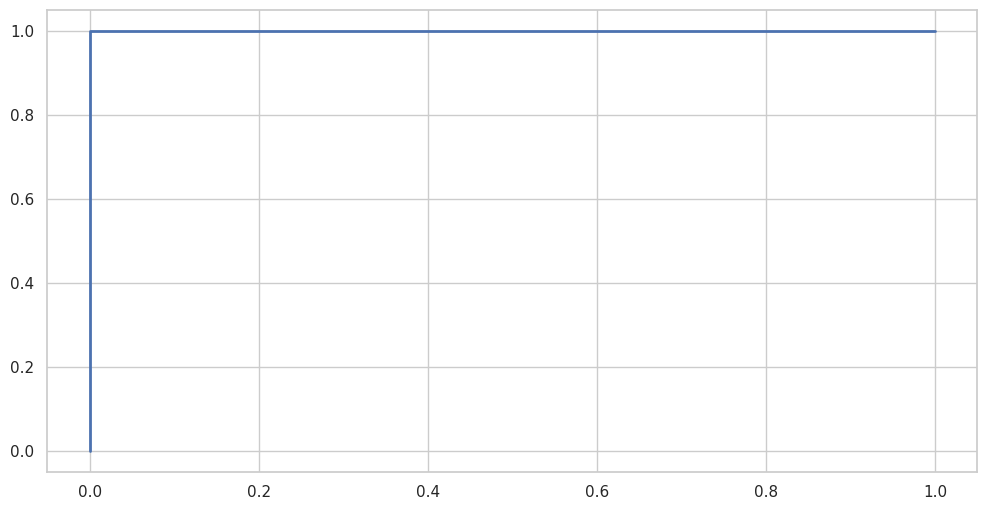

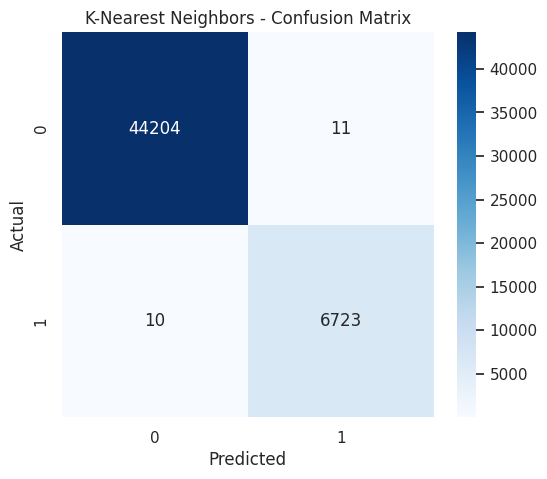

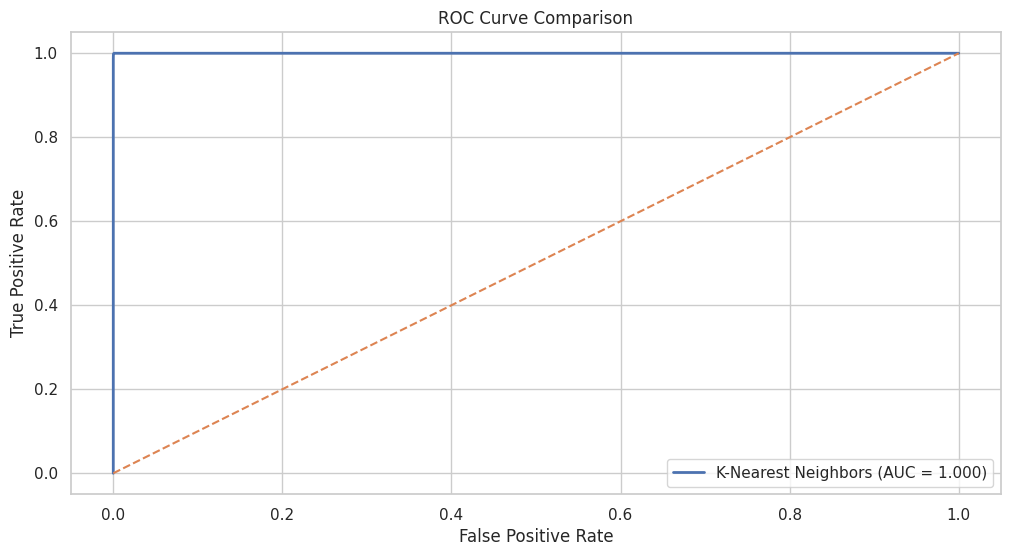



MODEL PERFORMANCE COMPARISON
                    Model  Accuracy  AUC Score
1           Decision Tree  1.000000   1.000000
2           Random Forest  1.000000   1.000000
3       Gradient Boosting  1.000000   1.000000
0     Logistic Regression  0.999980   1.000000
4  Support Vector Machine  0.999980   1.000000
5     K-Nearest Neighbors  0.999588   0.999987


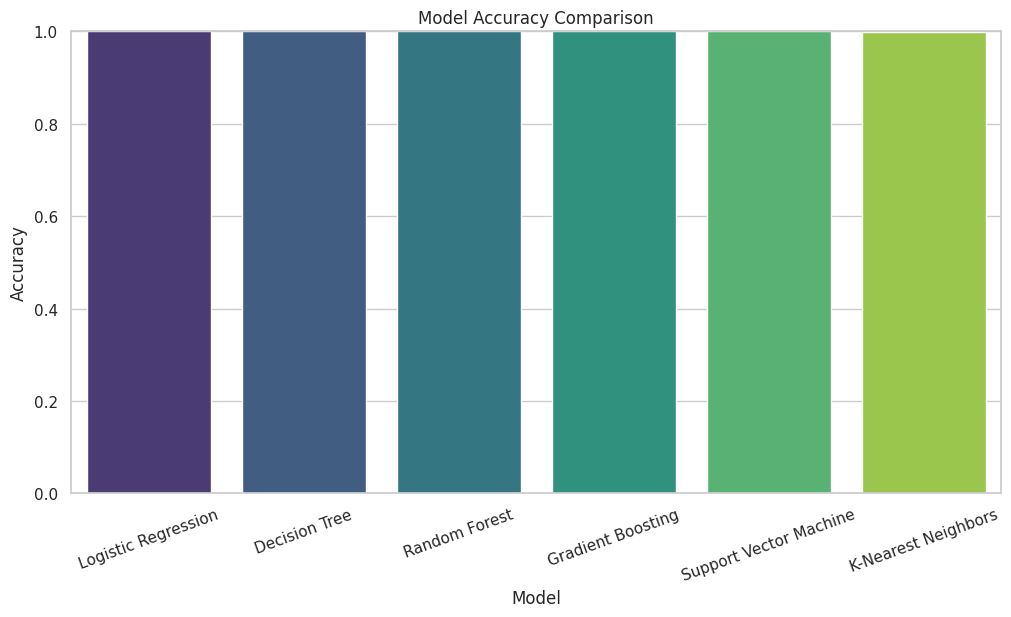

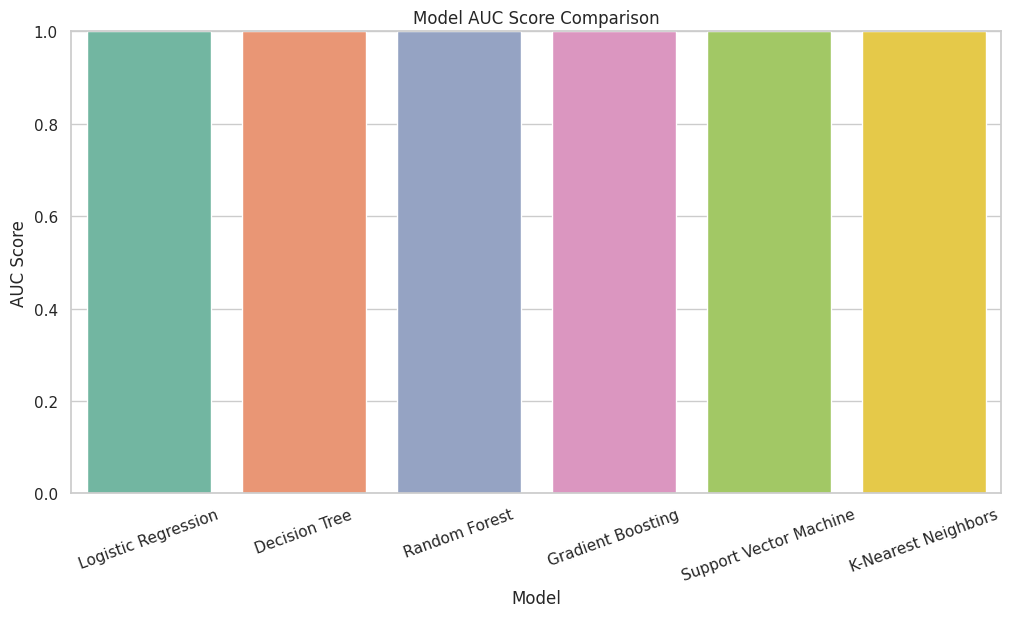



BEST MODEL
Model Name : Decision Tree
Accuracy   : 1.0000
AUC Score  : 1.0000


FEATURE IMPORTANCE - RANDOM FOREST
                   Feature  Importance
9             European_AQI    0.348583
46  AQI_Category_Unhealthy    0.161231
2               PM10_ug_m3    0.105721
44  AQI_Category_Hazardous    0.081099
45   AQI_Category_Moderate    0.078700
3              PM2_5_ug_m3    0.078030
7               Dust_ug_m3    0.048865
37             City_Riyadh    0.027974
1                Longitude    0.019502
43       AQI_Category_Good    0.011430
20              City_Delhi    0.008457
4    Carbon_Monoxide_ug_m3    0.007433
15            City_Beijing    0.004257
24            City_Jakarta    0.003754
6              Ozone_ug_m3    0.003232


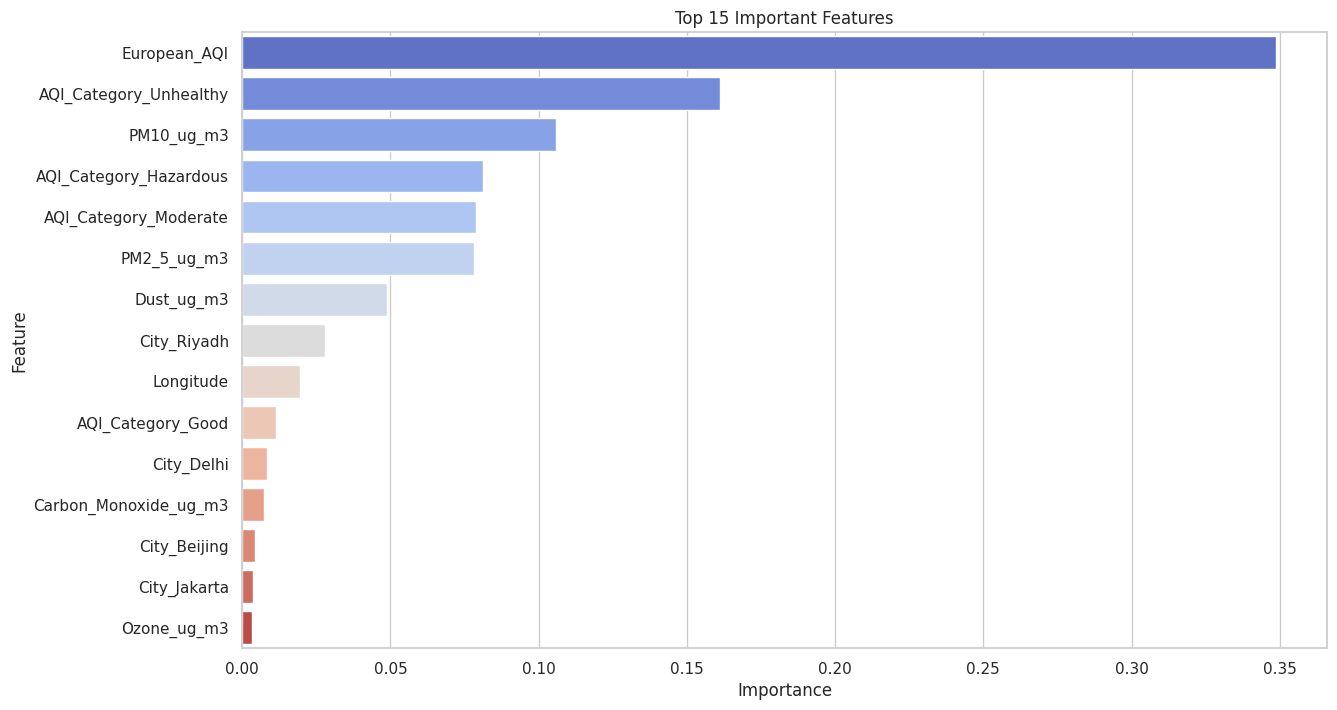


Machine Learning Pipeline Completed Successfully!


In [16]:
# =========================================================
# CONVERT TIMESTAMP
# =========================================================

df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Extract useful time features
df['Year'] = df['Timestamp'].dt.year
df['Month'] = df['Timestamp'].dt.month
df['Day'] = df['Timestamp'].dt.day
df['Hour'] = df['Timestamp'].dt.hour

# Drop original timestamp
df.drop('Timestamp', axis=1, inplace=True)

# =========================================================
# LABEL ENCODING TARGET
# =========================================================

# Convert target labels into numbers

label_encoder = LabelEncoder()

df['Hazardous_Event'] = label_encoder.fit_transform(
    df['Hazardous_Event']
)

print("\nTarget Classes:")
print(label_encoder.classes_)

# =========================================================
# DEFINE FEATURES AND TARGET
# =========================================================

X = df.drop('Hazardous_Event', axis=1)

y = df['Hazardous_Event']

# =========================================================
# IDENTIFY COLUMN TYPES
# =========================================================

categorical_columns = X.select_dtypes(
    include=['object']
).columns.tolist()

numerical_columns = X.select_dtypes(
    exclude=['object']
).columns.tolist()

print("\nCategorical Columns:")
print(categorical_columns)

print("\nNumerical Columns:")
print(numerical_columns)

# =========================================================
# TRAIN TEST SPLIT
# =========================================================
# IMPORTANT:
# Splitting BEFORE preprocessing avoids data leakage

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

# =========================================================
# PREPROCESSING PIPELINE
# =========================================================

# Numerical Pipeline
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Pipeline
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine both pipelines
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_columns),
    ('cat', categorical_pipeline, categorical_columns)
])

# =========================================================
# MACHINE LEARNING MODELS
# =========================================================

models = {

    "Logistic Regression":
        LogisticRegression(),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "Support Vector Machine":
        SVC(
            probability=True,
            random_state=42
        ),

    "K-Nearest Neighbors":
        KNeighborsClassifier(n_neighbors=5)
}

# =========================================================
# STORE RESULTS
# =========================================================

results = []

# =========================================================
# ROC CURVE FIGURE
# =========================================================

plt.figure(figsize=(12,8))

# =========================================================
# TRAINING LOOP
# =========================================================

for model_name, model in models.items():

    print("\n")
    print("="*60)
    print(f"MODEL : {model_name}")
    print("="*60)

    # =========================================
    # CREATE FULL PIPELINE
    # =========================================

    full_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # =========================================
    # TRAIN MODEL
    # =========================================

    full_pipeline.fit(X_train, y_train)

    # =========================================
    # PREDICTIONS
    # =========================================

    y_pred = full_pipeline.predict(X_test)

    # Probability predictions for ROC curve
    y_prob = full_pipeline.predict_proba(X_test)[:,1]

    # =========================================
    # ACCURACY
    # =========================================

    accuracy = accuracy_score(y_test, y_pred)

    print(f"\nAccuracy Score : {accuracy:.4f}")

    # =========================================
    # CLASSIFICATION REPORT
    # =========================================

    print("\nClassification Report:\n")

    print(classification_report(y_test, y_pred))

    # =========================================
    # CONFUSION MATRIX
    # =========================================

    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix:\n")
    print(cm)

    # =========================================
    # VISUALIZE CONFUSION MATRIX
    # =========================================

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    # =========================================
    # ROC CURVE
    # =========================================

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    roc_auc = auc(fpr, tpr)

    # Plot ROC
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{model_name} (AUC = {roc_auc:.3f})'
    )

    # =========================================
    # STORE RESULTS
    # =========================================

    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'AUC Score': roc_auc
    })

# =========================================================
# FINAL ROC CURVE
# =========================================================

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

# =========================================================
# RESULTS TABLE
# =========================================================

results_df = pd.DataFrame(results)

print("\n")
print("="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)

print(results_df.sort_values(
    by='Accuracy',
    ascending=False
))

# =========================================================
# VISUALIZE MODEL ACCURACY
# =========================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results_df,
    palette='viridis'
)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=20)

plt.ylim(0,1)

plt.show()

# =========================================================
# VISUALIZE AUC SCORES
# =========================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x='Model',
    y='AUC Score',
    data=results_df,
    palette='Set2'
)

plt.title("Model AUC Score Comparison")

plt.xticks(rotation=20)

plt.ylim(0,1)

plt.show()

# =========================================================
# BEST MODEL
# =========================================================

best_model = results_df.sort_values(
    by='Accuracy',
    ascending=False
).iloc[0]

print("\n")
print("="*60)
print("BEST MODEL")
print("="*60)

print(f"Model Name : {best_model['Model']}")
print(f"Accuracy   : {best_model['Accuracy']:.4f}")
print(f"AUC Score  : {best_model['AUC Score']:.4f}")

# =========================================================
# FEATURE IMPORTANCE (RANDOM FOREST)
# =========================================================

print("\n")
print("="*60)
print("FEATURE IMPORTANCE - RANDOM FOREST")
print("="*60)

# Train Random Forest pipeline separately
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

# Get feature names after encoding
encoded_cat_features = rf_pipeline.named_steps[
    'preprocessor'
].transformers_[1][1].named_steps[
    'encoder'
].get_feature_names_out(categorical_columns)

all_features = numerical_columns + list(encoded_cat_features)

# Feature importance
importance = rf_pipeline.named_steps[
    'model'
].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importance
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance_df.head(15))

# =========================================================
# FEATURE IMPORTANCE PLOT
# =========================================================

plt.figure(figsize=(14,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df.head(15),
    palette='coolwarm'
)

plt.title("Top 15 Important Features")

plt.show()

# =========================================================
# END
# =========================================================

print("\nMachine Learning Pipeline Completed Successfully!")

## thank you...pls upovte!!!!!!!!!!